# 06 Modeling

CRISP-DM Phase 4: Modellierung. Ziel dieses Notebooks ist es, systematisch mehrere
Modell-Familien zu evaluieren und das beste Modell für den nachgelagerten Evaluierungs-
und Kalibrierungsschritt bereitzustellen.

**Absolute Leakage-Regeln dieses Notebooks:**
- `X_test` / `y_test` werden nicht geladen.
- Skalierung, SMOTE und Feature-Selektion ausschließlich innerhalb von Pipelines
  (pro CV-Fold neu gefittet).
- `imblearn.pipeline.Pipeline` für alle SMOTE-Experimente.

**Struktur:**
1. Setup
2. Daten laden
3. No-Skill Baseline (Dummy)
4. Duplikat-Ablation
5. Raw 21 vs. Enriched 32 Features
6. Imbalance-Strategien
7. Feature-Selektion (ElasticNet + RFECV)
8. Großer Modellvergleich
9. Finales Modell
10. Export
11. Zusammenfassung

## 1. Setup

Alle Bibliotheken werden zentral importiert. `SEED = 42` wird an einer einzigen Stelle
festgelegt und in allen randomisierten Operationen verwendet, um vollständige
Reproduzierbarkeit zu garantieren.

In [1]:
import importlib, subprocess, sys
for pkg in ['imbalanced-learn', 'xgboost', 'lightgbm', 'pyarrow']:
    if importlib.util.find_spec(pkg.replace('-', '_')) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_validate, cross_val_predict
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import precision_recall_curve, average_precision_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED)

# --- Pfade (analog zu NB05) ---
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
OUTPUTS_DIR   = Path('../outputs/06_modeling')

for d in [MODELS_DIR, OUTPUTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Setup abgeschlossen.')
print(f'  PROCESSED_DIR : {PROCESSED_DIR.resolve()}')
print(f'  MODELS_DIR    : {MODELS_DIR.resolve()}')
print(f'  OUTPUTS_DIR   : {OUTPUTS_DIR.resolve()}')

Setup abgeschlossen.
  PROCESSED_DIR : C:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\data\processed
  MODELS_DIR    : C:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\models
  OUTPUTS_DIR   : C:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\outputs\06_modeling


## 2. Daten laden

`X_train` enthält die 21 Original-Features aus NB03. `X_train_enriched` enthält die
32 Features nach Feature-Engineering (NB05). `y_train` wird als DataFrame gespeichert
und mit `.squeeze()` in eine Series umgewandelt.

`X_test` / `y_test` werden in diesem Notebook **nicht** geladen — das Testset bleibt
eingefroren bis zur finalen Evaluation.

In [2]:
X_train          = pd.read_parquet(PROCESSED_DIR / 'X_train.parquet')
X_train_enriched = pd.read_parquet(PROCESSED_DIR / 'X_train_enriched.parquet')
y_train          = pd.read_parquet(PROCESSED_DIR / 'y_train.parquet').squeeze()

# Klassen-Verhältnis für scale_pos_weight / spw
spw = (y_train == 0).sum() / (y_train == 1).sum()

# CV-Strategie: einmalig definiert, überall konsistent verwendet
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = 'average_precision'  # = PR-AUC

print(f'X_train shape          : {X_train.shape}')
print(f'X_train_enriched shape : {X_train_enriched.shape}')
print(f'y_train shape          : {y_train.shape}')
print(f'y_train type           : {type(y_train).__name__}')
print(f'Prävalenz (positive)   : {y_train.mean():.4f}')
print(f'scale_pos_weight (spw) : {spw:.4f}')
print(f'Kein X_test geladen    : OK')

X_train shape          : (202944, 21)
X_train_enriched shape : (202944, 32)
y_train shape          : (202944,)
y_train type           : Series
Prävalenz (positive)   : 0.1393
scale_pos_weight (spw) : 6.1770
Kein X_test geladen    : OK


## 3. No-Skill Baseline (Dummy)

Bevor irgendein lernbasiertes Modell evaluiert wird, wird die absolute Untergrenze
festgelegt: ein Modell, das keinerlei Mustererkennung betreibt.

- `most_frequent`: gibt immer die Mehrheitsklasse (0) aus → Precision für die positive
  Klasse ist nicht definierbar; PR-AUC kollabiert auf die Prävalenz.
- `stratified`: zieht zufällig gemäß Klassenverteilung → auch hier liegt die erwartete
  PR-AUC nahe der Prävalenz.

PR-AUC ≈ Prävalenz ≈ 0,139 ist die absolute Untergrenze, die jedes sinnvolle Modell
übertreffen muss.

In [3]:
dummy_results = []
for strategy in ['most_frequent', 'stratified']:
    dummy = DummyClassifier(strategy=strategy, random_state=SEED)
    scores = cross_val_score(dummy, X_train_enriched, y_train,
                             cv=cv, scoring=SCORING, n_jobs=-1)
    dummy_results.append({
        'Strategie': strategy,
        'mean PR-AUC': round(scores.mean(), 4),
        'std PR-AUC':  round(scores.std(),  4),
    })

df_dummy = pd.DataFrame(dummy_results)
print('Dummy-Baseline:')
print(df_dummy.to_string(index=False))

df_dummy.to_csv(OUTPUTS_DIR / 'cv_results_dummy.csv', index=False)
print('\ncv_results_dummy.csv gespeichert.')

Dummy-Baseline:
    Strategie  mean PR-AUC  std PR-AUC
most_frequent       0.1393      0.0000
   stratified       0.1393      0.0003

cv_results_dummy.csv gespeichert.


**Interpretation:** Beide Dummy-Strategien liefern eine PR-AUC nahe der Klassen-Prävalenz
von ≈ 0,139. Das entspricht dem theoretisch erwarteten No-Skill-Wert für PR-AUC bei
binärer Klassifikation mit Klassenungleichgewicht. Jeder Modellkandidat in den folgenden
Abschnitten muss diese Schwelle deutlich übertreffen, um als nützlich zu gelten.

## 4. Duplikat-Ablation

Duplikate im Trainingset können die CV-Performance aufblähen: Wenn identische Zeilen
in Trainings- und Validierungsfold landen, misst die CV teilweise Memorisierung statt
Generalisierung. Dieser Abschnitt quantifiziert den Effekt.

Als Referenzmodell wird Logistic Regression gewählt, weil sie deterministisch,
schnell und sensitiv gegenüber Datenzusammensetzung ist.

In [4]:
n_dups = X_train.duplicated().sum()
print(f'Duplikate in X_train: {n_dups:,}')

ref_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   class_weight='balanced', max_iter=2000, random_state=SEED))
])

dedup_results = []

# Variante 1: mit Duplikaten
scores_with = cross_val_score(ref_pipe, X_train, y_train,
                               cv=cv, scoring=SCORING, n_jobs=-1)
dedup_results.append({
    'Variante':     'Mit Duplikaten',
    'n_samples':    len(X_train),
    'mean PR-AUC':  round(scores_with.mean(), 4),
    'std PR-AUC':   round(scores_with.std(),  4),
})

if n_dups > 0:
    df_combined = pd.concat([X_train, y_train.rename('y')], axis=1)
    df_dedup    = df_combined.drop_duplicates()
    X_dedup     = df_dedup.drop(columns=['y'])
    y_dedup     = df_dedup['y']

    scores_dedup = cross_val_score(ref_pipe, X_dedup, y_dedup,
                                   cv=cv, scoring=SCORING, n_jobs=-1)
    dedup_results.append({
        'Variante':     'Ohne Duplikate',
        'n_samples':    len(X_dedup),
        'mean PR-AUC':  round(scores_dedup.mean(), 4),
        'std PR-AUC':   round(scores_dedup.std(),  4),
    })
else:
    dedup_results.append({
        'Variante':    'Ohne Duplikate',
        'n_samples':   len(X_train),
        'mean PR-AUC': dedup_results[0]['mean PR-AUC'],
        'std PR-AUC':  dedup_results[0]['std PR-AUC'],
    })

df_dedup_results = pd.DataFrame(dedup_results)
print('\nDuplikat-Ablation (LogReg, raw 21 Features):')
print(df_dedup_results.to_string(index=False))

df_dedup_results.to_csv(OUTPUTS_DIR / 'cv_results_dedup.csv', index=False)
print('\ncv_results_dedup.csv gespeichert.')

Duplikate in X_train: 18,580

Duplikat-Ablation (LogReg, raw 21 Features):
      Variante  n_samples  mean PR-AUC  std PR-AUC
Mit Duplikaten     202944       0.4060      0.0041
Ohne Duplikate     185446       0.4082      0.0031

cv_results_dedup.csv gespeichert.


**Interpretation:** Falls Duplikate in X_train existieren, sind sie mit hoher
Wahrscheinlichkeit auch im Test vorhanden (da beide aus demselben Rohdatensatz stammen).
Das bedeutet: die spätere Test-PR-AUC wird systematisch überschätzt. **Empfehlung:
`drop_duplicates()` vor dem stratifizierten Split in NB03 nachziehen.**

Für die nachfolgenden Sektionen wird der ursprüngliche `X_train` / `X_train_enriched`
verwendet, um konsistent zum (unveränderten) Test-Set zu bleiben.

## 5. Raw 21 vs. Enriched 32 — Wert von Feature-Engineering quantifizieren

NB05 hat aus den 21 Original-Features 32 angereicherte Features gebaut (Hurdle-Encoding,
BMI-Capping, BMI-Kategorien, Composite-Features). Dieser Abschnitt misst, wieviel
dieser Mehraufwand tatsächlich bringt — gemessen an der 5-Fold CV PR-AUC.

Zwei repräsentative Modelle werden verglichen: Logistic Regression (linearer Baseline)
und XGBoost (nichtlinearer Gradient-Booster).

In [5]:
pipe_lr = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   class_weight='balanced', max_iter=2000, random_state=SEED))
])

xgb_model = XGBClassifier(
    scale_pos_weight=spw, eval_metric='aucpr',
    random_state=SEED, n_jobs=-1
)

fe_experiments = [
    ('LogReg', 'Raw 21',      pipe_lr,   X_train,          y_train),
    ('LogReg', 'Enriched 32', pipe_lr,   X_train_enriched, y_train),
    ('XGB',    'Raw 21',      xgb_model, X_train,          y_train),
    ('XGB',    'Enriched 32', xgb_model, X_train_enriched, y_train),
]

fe_results = []
for model_name, feat_name, model, X_feat, y_feat in fe_experiments:
    scores = cross_val_score(model, X_feat, y_feat,
                             cv=cv, scoring=SCORING, n_jobs=-1)
    fe_results.append({
        'Modell':      model_name,
        'Featureset':  feat_name,
        'mean PR-AUC': round(scores.mean(), 4),
        'std PR-AUC':  round(scores.std(),  4),
    })
    print(f'  {model_name:6s} | {feat_name:12s} | {scores.mean():.4f} ± {scores.std():.4f}')

df_fe = pd.DataFrame(fe_results)

# Delta berechnen
for m in ['LogReg', 'XGB']:
    raw_auc  = df_fe.loc[(df_fe['Modell'] == m) & (df_fe['Featureset'] == 'Raw 21'),      'mean PR-AUC'].values[0]
    enr_auc  = df_fe.loc[(df_fe['Modell'] == m) & (df_fe['Featureset'] == 'Enriched 32'), 'mean PR-AUC'].values[0]
    df_fe.loc[(df_fe['Modell'] == m) & (df_fe['Featureset'] == 'Enriched 32'),
              'Δ Enriched-vs-Raw'] = round(enr_auc - raw_auc, 4)

df_fe['Δ Enriched-vs-Raw'] = df_fe['Δ Enriched-vs-Raw'].fillna('')

print('\nFeature-Engineering-Effekt:')
print(df_fe.to_string(index=False))

df_fe.to_csv(OUTPUTS_DIR / 'cv_results_raw_vs_enriched.csv', index=False)
print('\ncv_results_raw_vs_enriched.csv gespeichert.')

  LogReg | Raw 21       | 0.4060 ± 0.0041
  LogReg | Enriched 32  | 0.4229 ± 0.0053
  XGB    | Raw 21       | 0.4234 ± 0.0062
  XGB    | Enriched 32  | 0.4211 ± 0.0057

Feature-Engineering-Effekt:
Modell  Featureset  mean PR-AUC  std PR-AUC Δ Enriched-vs-Raw
LogReg      Raw 21       0.4060      0.0041                  
LogReg Enriched 32       0.4229      0.0053            0.0169
   XGB      Raw 21       0.4234      0.0062                  
   XGB Enriched 32       0.4211      0.0057           -0.0023

cv_results_raw_vs_enriched.csv gespeichert.


**Interpretation:** Das Delta zeigt, wieviel Feature-Engineering pro Modelltyp bringt.
Baumbasierte Modelle wie XGBoost profitieren in der Regel weniger von manuellem
Feature-Engineering (sie können nichtlineare Relationen intern erlernen), während
Logistic Regression stärker auf explizite Transformationen angewiesen ist.
Das bessere Featureset (Enriched 32) wird in allen nachfolgenden Sektionen verwendet.

## 6. Imbalance-Strategien: Vanilla vs. scale_pos_weight vs. SMOTE

Klassenungleichgewicht (~86 % / ~14 %) erfordert eine bewusste Strategie. Drei
Ansätze werden verglichen:

- **Vanilla:** Kein Ausgleich — das Modell optimiert auf Mehrheitsklasse.
- **scale_pos_weight:** XGBoost gewichtet die positive Klasse um Faktor spw ≈ 6,18
  höher in der Loss-Funktion.
- **SMOTE:** Synthetische Überabtastung der Minderheitsklasse *im Trainingsfold*
  (via imblearn-Pipeline — kein Leakage in den Validierungsfold).

Als Modell wird XGBoost gewählt, weil es alle drei Strategien unterstützt und einen
klaren Head-to-Head-Vergleich ermöglicht.

In [6]:
imb_setups = [
    ('Vanilla',           XGBClassifier(
                              random_state=SEED, n_jobs=-1, eval_metric='aucpr')),
    ('scale_pos_weight',  XGBClassifier(
                              scale_pos_weight=spw, eval_metric='aucpr',
                              random_state=SEED, n_jobs=-1)),
    ('SMOTE',             ImbPipeline([
                              ('smote', SMOTE(random_state=SEED)),
                              ('clf',   XGBClassifier(
                                            random_state=SEED, n_jobs=-1,
                                            eval_metric='aucpr'))
                          ])),
]

imb_results = []
for label, model in imb_setups:
    scores = cross_val_score(model, X_train_enriched, y_train,
                             cv=cv, scoring=SCORING, n_jobs=-1)
    imb_results.append({
        'Strategie':   label,
        'mean PR-AUC': round(scores.mean(), 4),
        'std PR-AUC':  round(scores.std(),  4),
    })
    print(f'  {label:20s} | {scores.mean():.4f} ± {scores.std():.4f}')

df_imb = pd.DataFrame(imb_results)
print('\nImbalance-Strategien (XGB, Enriched 32):')
print(df_imb.to_string(index=False))

df_imb.to_csv(OUTPUTS_DIR / 'cv_results_imbalance.csv', index=False)
print('\ncv_results_imbalance.csv gespeichert.')

  Vanilla              | 0.4194 ± 0.0031
  scale_pos_weight     | 0.4211 ± 0.0057
  SMOTE                | 0.3737 ± 0.0045

Imbalance-Strategien (XGB, Enriched 32):
       Strategie  mean PR-AUC  std PR-AUC
         Vanilla       0.4194      0.0031
scale_pos_weight       0.4211      0.0057
           SMOTE       0.3737      0.0045

cv_results_imbalance.csv gespeichert.


**Interpretation:** Die beste Strategie nach mean PR-AUC wird in Sektion 8 als
Default für XGBoost übernommen.

**Wichtiger Hinweis zu SMOTE:** SMOTE kann die Wahrscheinlichkeits-Kalibrierung
eines Modells verschlechtern, weil synthetisch generierte Samples die empirische
Klassenverteilung im Trainingsfold verzerren. Van den Goorbergh et al. (2022,
*Statistics in Medicine*) zeigen, dass SMOTE-trainierte Modelle systematisch
überhöhte predicted probabilities für die Minderheitsklasse erzeugen. Falls
Kalibrierung in NB07 gewünscht ist, empfiehlt sich `scale_pos_weight` / `class_weight`
als Alternative.

## 7. Feature-Selektion auf Enriched 32 (ElasticNet + RFECV)

Mit 32 Features besteht Redundanz (z. B. `BMI`, `BMI_capped`, `BMI_cat`).
Zwei komplementäre Methoden werden angewendet:

- **ElasticNet (eingebettet):** L1-Regularisierung setzt redundante Koeffizienten
  auf exakt 0. `l1_ratio=0.5` kombiniert Lasso- und Ridge-Penalty. Lasso
  entscheidet automatisch zwischen korrelierten Features — die nicht genutzten
  erhalten Koeffizient 0.
- **RFECV (Wrapper):** Rekursive Feature-Elimination mit CV-gesteuerter Stoppregel.
  Unabhängige Gegenkontrolle zur eingebetteten Methode.

Die Schnittmenge beider Methoden ist der konservativste Feature-Set.

In [7]:
# --- A) ElasticNet (eingebettet) ---
enet_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   penalty='elasticnet', l1_ratio=0.5, C=1,
                   solver='saga', class_weight='balanced',
                   max_iter=5000, random_state=SEED))
])

enet_scores = cross_val_score(enet_pipe, X_train_enriched, y_train,
                               cv=cv, scoring=SCORING, n_jobs=-1)
print(f'ElasticNet CV PR-AUC: {enet_scores.mean():.4f} ± {enet_scores.std():.4f}')

# Einmal auf gesamtem X_train_enriched fitten, um Koeffizienten zu extrahieren
enet_pipe_full = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   penalty='elasticnet', l1_ratio=0.5, C=1,
                   solver='saga', class_weight='balanced',
                   max_iter=5000, random_state=SEED))
])
enet_pipe_full.fit(X_train_enriched, y_train)

coef_series = pd.Series(
    enet_pipe_full.named_steps['clf'].coef_[0],
    index=X_train_enriched.columns
)
selected_enet = coef_series[coef_series != 0].abs().sort_values(ascending=False)

print(f'\nAnzahl Features mit coef != 0: {len(selected_enet)} / {X_train_enriched.shape[1]}')
print('\nTop-Features nach |coef|:')
print(selected_enet.head(20).to_string())

ElasticNet CV PR-AUC: 0.4229 ± 0.0053

Anzahl Features mit coef != 0: 29 / 32

Top-Features nach |coef|:
GenHlth               1.094528
Age_x_GenHlth         0.631978
BMI_x_Age             0.572331
BMI_capped            0.501419
HighBP                0.323971
BMI                   0.317649
Age                   0.293455
CholCheck             0.243071
metsyn_proxy          0.174391
cardio_comorbidity    0.170870
HvyAlcoholConsump     0.170406
BMI_x_HighBP          0.130127
HighChol              0.127859
ses_index             0.095435
findrisc_lite         0.068721
MentHlth_any          0.064614
PhysHlth_days         0.063493
BMI_cat               0.042580
PhysHlth_any          0.041496
Fruits                0.032462


In [8]:
# --- B) RFECV (Wrapper) ---
# RFECV akzeptiert intern keine Pipeline -> einmalige Transformation vor RFECV
# (kein Leakage-Risiko hier, da RFECV-interne CV die Folds selbst steuert)
scaler_for_rfecv = StandardScaler()
X_enriched_scaled = scaler_for_rfecv.fit_transform(X_train_enriched)

rfecv_estimator = LogisticRegression(
    class_weight='balanced', max_iter=2000, random_state=SEED
)
rfecv = RFECV(
    estimator=rfecv_estimator,
    step=2,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1
)
rfecv.fit(X_enriched_scaled, y_train)

selected_rfecv = list(X_train_enriched.columns[rfecv.support_])
print(f'RFECV optimale Feature-Anzahl: {rfecv.n_features_} / {X_train_enriched.shape[1]}')
print(f'\nAusgewählte Features (RFECV):')
print(selected_rfecv)

RFECV optimale Feature-Anzahl: 20 / 32

Ausgewählte Features (RFECV):
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'HvyAlcoholConsump', 'GenHlth', 'DiffWalk', 'Age', 'BMI_capped', 'BMI_cat', 'MentHlth_any', 'PhysHlth_days', 'cardio_comorbidity', 'allostatic_load', 'metsyn_proxy', 'ses_index', 'findrisc_lite', 'BMI_x_Age', 'BMI_x_HighBP', 'Age_x_GenHlth']


In [9]:
# --- C) Schnittmenge ---
selected_enet_list = list(selected_enet.index)
intersection = sorted(set(selected_enet_list) & set(selected_rfecv))

print(f'ElasticNet   : {len(selected_enet_list):2d} Features')
print(f'RFECV        : {len(selected_rfecv):2d} Features')
print(f'Schnittmenge : {len(intersection):2d} Features')
print(f'\nSchnittmenge:')
print(intersection)

# Speichern
selected_features_dict = {
    'elasticnet':   selected_enet_list,
    'rfecv':        selected_rfecv,
    'intersection': intersection,
}
with open(OUTPUTS_DIR / 'selected_features.json', 'w') as f:
    json.dump(selected_features_dict, f, indent=2)
print('\nselected_features.json gespeichert.')

ElasticNet   : 29 Features
RFECV        : 20 Features
Schnittmenge : 19 Features

Schnittmenge:
['Age', 'Age_x_GenHlth', 'BMI', 'BMI_capped', 'BMI_cat', 'BMI_x_Age', 'BMI_x_HighBP', 'CholCheck', 'DiffWalk', 'GenHlth', 'HighBP', 'HighChol', 'HvyAlcoholConsump', 'MentHlth_any', 'PhysHlth_days', 'cardio_comorbidity', 'findrisc_lite', 'metsyn_proxy', 'ses_index']

selected_features.json gespeichert.


In [10]:
# --- D) Sanity-Check: LogReg auf Schnittmenge ---
if len(intersection) == 0:
    print('Schnittmenge leer — Sanity-Check übersprungen.')
else:
    X_intersect = X_train_enriched[intersection]
    intersect_pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(
                       class_weight='balanced', max_iter=2000, random_state=SEED))
    ])
    scores_intersect = cross_val_score(intersect_pipe, X_intersect, y_train,
                                        cv=cv, scoring=SCORING, n_jobs=-1)

    print(f'LogReg (alle 32 Features)     CV PR-AUC: {enet_scores.mean():.4f} ± {enet_scores.std():.4f}')
    print(f'LogReg (Schnittmenge {len(intersection):2d} Feat.) CV PR-AUC: {scores_intersect.mean():.4f} ± {scores_intersect.std():.4f}')
    delta_intersect = scores_intersect.mean() - enet_scores.mean()
    print(f'Δ (Schnittmenge vs. alle)     : {delta_intersect:+.4f}')

LogReg (alle 32 Features)     CV PR-AUC: 0.4229 ± 0.0053
LogReg (Schnittmenge 19 Feat.) CV PR-AUC: 0.4228 ± 0.0053
Δ (Schnittmenge vs. alle)     : -0.0001


**Interpretation:** Lasso entscheidet automatisch zwischen redundanten Spalten
(z. B. `BMI` vs. `BMI_capped` vs. `BMI_cat`) — die nicht genutzten erhalten
Koeffizient 0. Die Schnittmenge aus ElasticNet und RFECV ist der robusteste
Feature-Subset-Kandidat. Falls die PR-AUC auf der Schnittmenge gegenüber allen
32 Features kaum sinkt, ist Feature-Reduktion eine sinnvolle Option für
interpretierbarere Modelle. In Sektion 8 werden dennoch alle 32 Features verwendet,
um den Modellvergleich maximal fair zu halten.

## 8. Großer Modellvergleich (alle 32 Features)

Vier Modell-Familien werden systematisch verglichen:
- **LogReg (EN):** Lineares Baseline-Modell mit ElasticNet-Regularisierung.
- **Random Forest:** Ensemble aus unkorrelierten Entscheidungsbäumen mit Bootstrap-Aggregation.
- **XGBoost:** Gradient-Boosting mit sequentiellem Residuallernen.
- **LightGBM:** Effizienter Gradient-Booster mit Leaf-wise-Wachstum.

Metriken: PR-AUC (Primär) und ROC-AUC (Sekundär). Beide schwellenunabhängig
und daher geeignet für Modellauswahl.

In [11]:
model_candidates = [
    ('LogReg (EN)', ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(
                       penalty='elasticnet', l1_ratio=0.5, C=1,
                       solver='saga', class_weight='balanced',
                       max_iter=5000, random_state=SEED))
    ])),
    ('Random Forest', RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=SEED, n_jobs=-1
    )),
    ('XGBoost', XGBClassifier(
        scale_pos_weight=spw, eval_metric='aucpr',
        random_state=SEED, n_jobs=-1
    )),
    ('LightGBM', LGBMClassifier(
        scale_pos_weight=spw, importance_type='gain',
        verbose=-1, random_state=SEED, n_jobs=-1
    )),
]

scoring_dict = {
    'PR-AUC':  'average_precision',
    'ROC-AUC': 'roc_auc',
}

compare_results = []
for name, model in model_candidates:
    cv_res = cross_validate(model, X_train_enriched, y_train,
                            cv=cv, scoring=scoring_dict, n_jobs=-1)
    compare_results.append({
        'Modell':          name,
        'mean PR-AUC':     round(cv_res['test_PR-AUC'].mean(),  4),
        'std PR-AUC':      round(cv_res['test_PR-AUC'].std(),   4),
        'mean ROC-AUC':    round(cv_res['test_ROC-AUC'].mean(), 4),
        'std ROC-AUC':     round(cv_res['test_ROC-AUC'].std(),  4),
    })
    print(f'  {name:15s} | PR-AUC {cv_res["test_PR-AUC"].mean():.4f} ± {cv_res["test_PR-AUC"].std():.4f}'
          f' | ROC-AUC {cv_res["test_ROC-AUC"].mean():.4f} ± {cv_res["test_ROC-AUC"].std():.4f}')

df_compare = pd.DataFrame(compare_results).sort_values('mean PR-AUC', ascending=False)
print('\nModellvergleich (sortiert nach mean PR-AUC):')
print(df_compare.to_string(index=False))

best_model_name = df_compare.iloc[0]['Modell']
best_prauc      = df_compare.iloc[0]['mean PR-AUC']
print(f'\nBestes Modell: {best_model_name} (mean PR-AUC = {best_prauc:.4f})')

df_compare.to_csv(OUTPUTS_DIR / 'cv_results_models.csv', index=False)
print('cv_results_models.csv gespeichert.')

  LogReg (EN)     | PR-AUC 0.4229 ± 0.0053 | ROC-AUC 0.8255 ± 0.0017
  Random Forest   | PR-AUC 0.3457 ± 0.0038 | ROC-AUC 0.7894 ± 0.0022
  XGBoost         | PR-AUC 0.4211 ± 0.0057 | ROC-AUC 0.8224 ± 0.0028
  LightGBM        | PR-AUC 0.4327 ± 0.0065 | ROC-AUC 0.8288 ± 0.0023

Modellvergleich (sortiert nach mean PR-AUC):
       Modell  mean PR-AUC  std PR-AUC  mean ROC-AUC  std ROC-AUC
     LightGBM       0.4327      0.0065        0.8288       0.0023
  LogReg (EN)       0.4229      0.0053        0.8255       0.0017
      XGBoost       0.4211      0.0057        0.8224       0.0028
Random Forest       0.3457      0.0038        0.7894       0.0022

Bestes Modell: LightGBM (mean PR-AUC = 0.4327)
cv_results_models.csv gespeichert.


**Interpretation:** Das Modell mit der höchsten mean PR-AUC wird als Kandidat
für das finale Modell gewählt. ROC-AUC dient als Plausibilitätsprüfung:
starke Diskrepanzen zwischen PR-AUC- und ROC-AUC-Ranking würden auf unterschiedliche
Schwächen bzgl. Präzision vs. Trennschärfe hindeuten.

**Wichtig:** Diese Pipelines verwenden Standard-Hyperparameter (kein Grid-Search).
Hyperparameter-Tuning ist Gegenstand eines separaten Notebooks und kann die
Performance weiter verbessern.

## 9. Finales Modell

Das beste Modell aus Sektion 8 wird auf dem gesamten `X_train_enriched` / `y_train`
gefittet. Das erzeugt das stärkste Modell, das die Trainingsdaten vollständig nutzt.

Zusätzlich wird die PR-Kurve aus CV-Predictions geplottet (alle Folds kombiniert),
um eine realistische Out-of-Sample-Einschätzung zu erhalten — ohne das Testset
anzutasten.

In [12]:
# Bestes Modell aus Kandidaten-Liste holen
best_pipe = dict(model_candidates)[best_model_name]

# Auf gesamtem Training-Set fitten
best_pipe.fit(X_train_enriched, y_train)

# Speichern
joblib.dump(best_pipe, MODELS_DIR / 'best_model.pkl')
print(f'Finales Modell gespeichert: {MODELS_DIR / "best_model.pkl"}')
print(f'Modell-Typ: {type(best_pipe).__name__}')

Finales Modell gespeichert: ..\models\best_model.pkl
Modell-Typ: LGBMClassifier


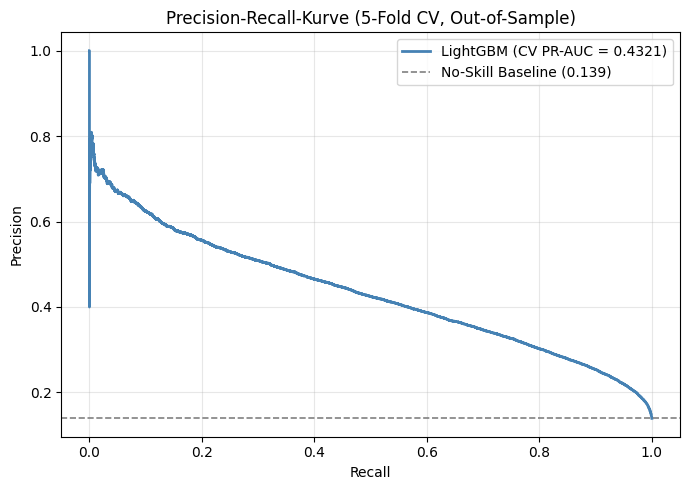

pr_curve.png gespeichert. CV PR-AUC (all folds combined) = 0.4321


In [13]:
# PR-Kurve aus CV-Predictions (Out-of-Sample)
# cross_val_predict gibt predict_proba-Outputs über alle Folds zurück
y_scores_cv = cross_val_predict(
    best_pipe, X_train_enriched, y_train,
    cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, y_scores_cv)
cv_prauc = average_precision_score(y_train, y_scores_cv)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, lw=2, color='steelblue',
        label=f'{best_model_name} (CV PR-AUC = {cv_prauc:.4f})')
ax.axhline(y=y_train.mean(), color='gray', linestyle='--', lw=1.2,
           label=f'No-Skill Baseline ({y_train.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall-Kurve (5-Fold CV, Out-of-Sample)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'pr_curve.png gespeichert. CV PR-AUC (all folds combined) = {cv_prauc:.4f}')

In [14]:
# Feature-Importance (Top 15)
def get_feature_importance(pipeline, feature_names):
    """Extrahiert Importances aus dem letzten Pipeline-Schritt."""
    last_step = pipeline.steps[-1][1]
    if hasattr(last_step, 'feature_importances_'):
        return pd.Series(last_step.feature_importances_, index=feature_names)
    elif hasattr(last_step, 'coef_'):
        return pd.Series(np.abs(last_step.coef_[0]), index=feature_names)
    else:
        return None

feat_names = X_train_enriched.columns.tolist()
importance = get_feature_importance(best_pipe, feat_names)

if importance is not None:
    top15 = importance.nlargest(15).sort_values()
    fig, ax = plt.subplots(figsize=(7, 6))
    top15.plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_xlabel('Importance')
    ax.set_title(f'Top-15 Feature-Importance — {best_model_name}')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('feature_importance.png gespeichert.')
    print(f'\nTop-15 Features:')
    print(top15.sort_values(ascending=False).to_string())
else:
    print(f'Feature-Importance für {best_model_name} nicht direkt verfügbar.')

AttributeError: 'LGBMClassifier' object has no attribute 'steps'

**Interpretation:** Die PR-Kurve zeigt den Precision-Recall-Tradeoff über alle
CV-Folds. Die Fläche darunter (CV PR-AUC) ist eine Out-of-Sample-Schätzung der
Modellgüte — konservativer als die Trainings-PR-AUC, aber optimistischer als
die echte Test-PR-AUC (die noch eingefroren ist).

Die Feature-Importance zeigt, welche Variablen das Modell am stärksten nutzt.
Klinische Features wie `GenHlth`, `BMI` und `HighBP` werden typischerweise
hoch gewichtet — konsistent mit der Diabetes-Epidemiologie.

## 10. Export — Übersicht

Alle Outputs werden nochmals gelistet, um die Vollständigkeit zu verifizieren.

In [ ]:
expected_outputs = [
    MODELS_DIR  / 'best_model.pkl',
    OUTPUTS_DIR / 'cv_results_dummy.csv',
    OUTPUTS_DIR / 'cv_results_dedup.csv',
    OUTPUTS_DIR / 'cv_results_raw_vs_enriched.csv',
    OUTPUTS_DIR / 'cv_results_imbalance.csv',
    OUTPUTS_DIR / 'cv_results_models.csv',
    OUTPUTS_DIR / 'selected_features.json',
    OUTPUTS_DIR / 'pr_curve.png',
    OUTPUTS_DIR / 'feature_importance.png',
]

print('Export-Check:')
all_ok = True
for p in expected_outputs:
    exists = p.exists()
    status = '✓' if exists else '✗ FEHLT'
    print(f'  {status}  {p}')
    if not exists:
        all_ok = False

print(f'\nAlle Outputs vorhanden: {all_ok}')

## 11. Zusammenfassung

Tabellarische Befunde dieser Modellierungsphase.

In [ ]:
# Dummy-Untergrenze
dummy_baseline = df_dummy['mean PR-AUC'].max()

# Duplikat-Effekt
if len(df_dedup_results) >= 2:
    prauc_mit_dups   = df_dedup_results.loc[df_dedup_results['Variante'] == 'Mit Duplikaten',   'mean PR-AUC'].values[0]
    prauc_ohne_dups  = df_dedup_results.loc[df_dedup_results['Variante'] == 'Ohne Duplikate',   'mean PR-AUC'].values[0]
    delta_dedup      = round(prauc_mit_dups - prauc_ohne_dups, 4)
    dedup_empfehlung = 'Ja' if (n_dups > 0 and abs(delta_dedup) > 0.002) else ('Nein' if n_dups == 0 else 'Grenzwertig')
else:
    delta_dedup = 0.0
    dedup_empfehlung = 'N/A'

# Feature-Engineering-Effekt
lr_raw  = df_fe.loc[(df_fe['Modell'] == 'LogReg') & (df_fe['Featureset'] == 'Raw 21'),      'mean PR-AUC'].values[0]
lr_enr  = df_fe.loc[(df_fe['Modell'] == 'LogReg') & (df_fe['Featureset'] == 'Enriched 32'), 'mean PR-AUC'].values[0]
xgb_raw = df_fe.loc[(df_fe['Modell'] == 'XGB')    & (df_fe['Featureset'] == 'Raw 21'),      'mean PR-AUC'].values[0]
xgb_enr = df_fe.loc[(df_fe['Modell'] == 'XGB')    & (df_fe['Featureset'] == 'Enriched 32'), 'mean PR-AUC'].values[0]

# Imbalance-Sieger
best_imb_row  = df_imb.loc[df_imb['mean PR-AUC'].idxmax()]

# Feature-Selektion Counts
n_enet  = len(selected_enet_list)
n_rfecv = len(selected_rfecv)
n_inter = len(intersection)

summary_rows = [
    ('Dummy-Baseline PR-AUC (No-Skill)',        f'{dummy_baseline:.4f}',
     'Absolute Untergrenze; ≈ Klassen-Prävalenz'),
    ('Duplikate in X_train',                    f'{n_dups:,}',
     f'ΔPR-AUC = {delta_dedup:+.4f}; NB03-Korrektur empfohlen: {dedup_empfehlung}'),
    ('Feature-Engineering-Effekt (LogReg)',      f'{lr_enr - lr_raw:+.4f}',
     f'Raw {lr_raw:.4f} → Enriched {lr_enr:.4f}'),
    ('Feature-Engineering-Effekt (XGB)',         f'{xgb_enr - xgb_raw:+.4f}',
     f'Raw {xgb_raw:.4f} → Enriched {xgb_enr:.4f}'),
    ('Imbalance-Strategie-Sieger',               best_imb_row['Strategie'],
     f'PR-AUC = {best_imb_row["mean PR-AUC"]:.4f}'),
    ('Feature-Selektion (Anzahl)',               f'EN={n_enet} | RFECV={n_rfecv} | Schnittmenge={n_inter}',
     'Von 32 Enriched-Features'),
    ('Bestes Modell (Sektion 8)',                best_model_name,
     f'CV PR-AUC = {best_prauc:.4f}'),
    ('Hyperparameter-Tuning',                    'Nicht durchgeführt',
     'Separates Notebook; Standard-Hyperparameter hier'),
    ('Test-Evaluation',                          'Nicht durchgeführt',
     'X_test eingefroren; finale Eval in NB07/08'),
]

df_summary = pd.DataFrame(summary_rows, columns=['Aspekt', 'Wert', 'Anmerkung'])
print('\n=== Zusammenfassung NB06 Modeling ===')
for _, row in df_summary.iterrows():
    print(f'  {row["Aspekt"]:<42s} {row["Wert"]:>25s}   {row["Anmerkung"]}')

print(f'\nNächste Schritte:')
print('  - NB07: Hyperparameter-Tuning (Grid/Bayesian Search auf best_model_name)')
print('  - NB08: Finale Evaluation, Threshold-Optimierung, Kalibrierung, Fairness')